# 🤖 Step 3: Model Training (1D CNN)

Build and train the 1D Convolutional Neural Network.

## What This Notebook Does:
- ✅ Load training data from CSV
- ✅ Build 1D CNN architecture
- ✅ Train the model
- ✅ Evaluate performance
- ✅ Save trained model

---

**Previous:** [02_preprocessing.ipynb](02_preprocessing.ipynb)  
**Next:** [04_prediction_analysis.ipynb](04_prediction_analysis.ipynb)

## Load Libraries and Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, MaxPooling1D, Dropout
import warnings
warnings.filterwarnings('ignore')

# Load training data
print("📂 Loading training data...")
df = pd.read_csv("outputs/training_data.csv")

print(f"✅ Data loaded!")
print(f"   Shape: {df.shape}")
print(f"   Features: B02, B03, B04, B08, NDVI")
print(f"   Target: Label (4 classes)")
print(f"\nClass distribution:")
print(df['Label'].value_counts().sort_index())

📂 Loading training data...
✅ Data loaded!
   Shape: (235764, 6)
   Features: B02, B03, B04, B08, NDVI
   Target: Label (4 classes)

Class distribution:
Label
1    73800
2    93955
3    68009
Name: count, dtype: int64


## Prepare Data for CNN

In [2]:
# Prepare features and labels
X = df[["B02", "B03", "B04", "B08", "NDVI"]].values
y = df["Label"].values

# Reshape for 1D CNN (samples, features, channels)
X = X.reshape(-1, 5, 1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set:   {X_train.shape[0]:,} samples")
print(f"Test set:       {X_test.shape[0]:,} samples")
print(f"Input shape:    {X_train.shape[1:]}")
print(f"Output classes: 4 (Cloud, Seagrass, Water, Sand)")

Training set:   188,611 samples
Test set:       47,153 samples
Input shape:    (5, 1)
Output classes: 4 (Cloud, Seagrass, Water, Sand)


## Build 1D CNN Model

**Architecture:**
- Conv1D layer (32 filters, kernel=2)
- MaxPooling1D
- Flatten
- Dense layers with Dropout
- Output: 4 classes (softmax)

In [3]:
# Build model
model = Sequential([
    Conv1D(32, kernel_size=2, activation='relu', input_shape=(5, 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("📊 Model Architecture:")
model.summary()

📊 Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 4, 32)          │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,468 (25.27 KB)

 Trainable params: 6,468 (25.27 KB)

 Non-trainable params: 0 (0.00 B)

## Train the Model

🚀 Training model...
Epoch 1/10
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9635 - loss: 0.1055 - val_accuracy: 0.9933 - val_loss: 0.0223
Epoch 2/10
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9906 - loss: 0.0234 - val_accuracy: 0.9951 - val_loss: 0.0154
Epoch 3/10
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9928 - loss: 0.0172 - val_accuracy: 0.9984 - val_loss: 0.0085
Epoch 4/10
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9945 - loss: 0.0134 - val_accuracy: 0.9985 - val_loss: 0.0058
Epoch 5/10
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9955 - loss: 0.0113 - val_accuracy: 0.9979 - val_loss: 0.0058
Epoch 6/10
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9962 - loss: 0.0095 - val_accuracy: 0.9967 - val_loss: 0.0068
Epoch 7/10
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9966 - loss: 0.0084 - val_accuracy: 0.9982 - val_loss: 0.0046
Epoch 8/10
2358/2358 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0

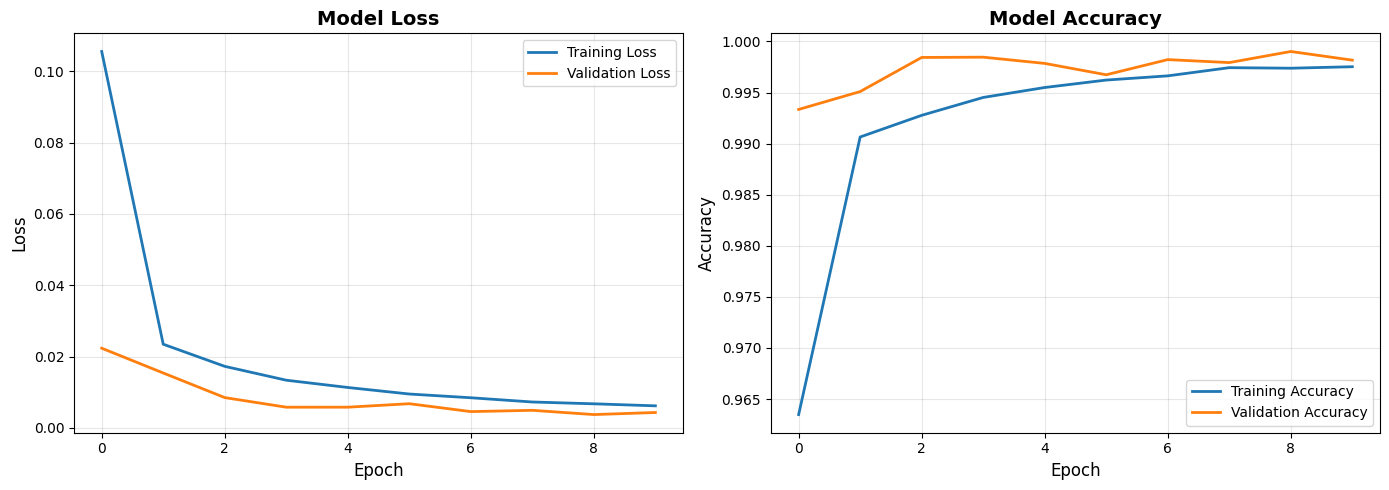


💾 Training history saved to 'outputs/03_training_history.png'


In [4]:
# Train model
print("🚀 Training model...")
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Evaluate
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Training Complete!")
print(f"   Test Accuracy: {test_accuracy*100:.2f}%")
print(f"   Test Loss: {test_loss:.4f}")

# Plot training history
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/03_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Training history saved to 'outputs/03_training_history.png'")

## Save the Model

In [5]:
# Save the trained model
model.save('outputs/coastal_cnn_model.h5')
print("💾 Model saved to 'outputs/coastal_cnn_model.h5'")

# Save metadata
import pickle
model_metadata = {
    'test_accuracy': test_accuracy,
    'test_loss': test_loss,
    'input_shape': (5, 1),
    'output_classes': 4,
    'class_names': {0: 'Cloud/No Data', 1: 'Seagrass', 2: 'Water', 3: 'Sand'}
}

with open('outputs/model_metadata.pkl', 'wb') as f:
    pickle.dump(model_metadata, f)

print("✅ Metadata saved to 'outputs/model_metadata.pkl'")
print("\n" + "="*60)
print("✅ MODEL TRAINING COMPLETE!")
print("="*60)
print(f"\nFinal Test Accuracy: {test_accuracy*100:.2f}%")
print("\n📌 Next Step: Open 04_prediction_analysis.ipynb to make predictions")

💾 Model saved to 'outputs/coastal_cnn_model.h5'
✅ Metadata saved to 'outputs/model_metadata.pkl'

✅ MODEL TRAINING COMPLETE!

Final Test Accuracy: 99.85%

📌 Next Step: Open 04_prediction_analysis.ipynb to make predictions
